# Analysis: GPU NR-Fix vs Baseline (F1 GPU + CPU)

**NR Fix**: TIP-INT derivative path now uses `computeTransDerivOnGPU` + `computeTipDerivTablesOnGPU`  
(same eigendecomposition formula as INT-INT path), replacing the host-side Q*P(t) computation.  

**Goal**: Verify numerical accuracy (lnL match) and compare optimization times.  

**Sources**:  
- NR Fix: `2026_03_16_bl_estimation_gpu_NR_fix` (GPU only, OPENACC)  
- Baseline: `2026_03_16_bl_estimation` (GPU OPENACC + CPU 1/10/48 cores + VANILA)

In [1]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

nrfix_path = "/Users/u7826985/Projects/Nvidia/results/2026_03_16_bl_estimation_gpu_NR_fix"
baseline_path = "/Users/u7826985/Projects/Nvidia/results/2026_03_16_bl_estimation"
save_dir = os.path.dirname(os.path.abspath('analysis.ipynb'))  # save plots next to notebook

## 1. Parse log files

In [2]:
alignment_pattern = re.compile(r"Alignment has (\d+) sequences with (\d+) columns, (\d+) distinct patterns")
initial_ll_pattern = re.compile(r"Initial log-likelihood:\s+([-0-9.]+)")
optimal_ll_pattern = re.compile(r"Optimal log-likelihood:\s+([-0-9.]+)")
params_opt_pattern = re.compile(r"Parameters optimization took (\d+) rounds? \(([0-9.]+) sec\)")
wallclock_pattern = re.compile(r"Total wall-clock time used:\s+([0-9.]+)\s+sec")

def parse_all_logs(results_path, source_label=None):
    """Parse all IQ-TREE log files and extract timing/likelihood data."""
    rows = []
    skipped = 0

    for data_type in ['AA', 'DNA']:
        data_dir = os.path.join(results_path, data_type)
        if not os.path.exists(data_dir):
            continue

        for tree_type in ['rooted', 'unrooted']:
            tree_type_dir = os.path.join(data_dir, tree_type)
            if not os.path.exists(tree_type_dir):
                continue

            for model in sorted(os.listdir(tree_type_dir)):
                model_dir = os.path.join(tree_type_dir, model)
                if not os.path.isdir(model_dir):
                    continue

                for tree_folder in sorted(os.listdir(model_dir)):
                    tree_dir = os.path.join(model_dir, tree_folder)
                    if not os.path.isdir(tree_dir):
                        continue

                    for fname in os.listdir(tree_dir):
                        if not fname.endswith('.log'):
                            continue

                        filepath = os.path.join(tree_dir, fname)
                        with open(filepath, 'r') as f:
                            content = f.read()

                        # Determine backend
                        if 'GPU_NR' in fname:
                            backend = 'GPU_NR_fix'
                        elif 'OPENACC' in fname:
                            backend = 'GPU_F1'
                        elif 'OMP_48' in fname:
                            backend = 'CPU_48'
                        elif 'OMP_10' in fname:
                            backend = 'CPU_10'
                        elif 'VANILA' in fname:
                            backend = 'CPU_1'
                        else:
                            continue

                        run_matches = re.findall(r'_run(\d+)_', fname)
                        run_number = int(run_matches[-1]) if run_matches else None

                        aln_match = alignment_pattern.search(content)
                        init_ll_match = initial_ll_pattern.search(content)
                        opt_ll_match = optimal_ll_pattern.search(content)
                        opt_match = params_opt_pattern.search(content)
                        wc_match = wallclock_pattern.search(content)

                        if aln_match and init_ll_match and opt_match and wc_match:
                            rows.append({
                                'data_type': data_type,
                                'tree_type': tree_type,
                                'model': model,
                                'treefile': tree_folder,
                                'backend': backend,
                                'run': run_number,
                                'initial_ll': float(init_ll_match.group(1)),
                                'optimal_ll': float(opt_ll_match.group(1)) if opt_ll_match else float(init_ll_match.group(1)),
                                'opt_rounds': int(opt_match.group(1)),
                                'opt_time': float(opt_match.group(2)),
                                'wallclock': float(wc_match.group(1)),
                            })
                        else:
                            skipped += 1

    df = pd.DataFrame(rows)
    if source_label:
        df['source'] = source_label
    print(f"Parsed {len(df)} logs from {results_path.split('/')[-1]} ({skipped} skipped)")
    return df

In [3]:
df_nrfix = parse_all_logs(nrfix_path, 'NR_fix')
df_baseline = parse_all_logs(baseline_path, 'baseline')

df_all = pd.concat([df_nrfix, df_baseline], ignore_index=True)
print(f"\nTotal: {len(df_all)} records")
print(f"\nBackend counts:")
print(df_all.groupby('backend').size())
print(f"\nData types x tree types:")
print(df_all.groupby(['data_type', 'tree_type', 'backend']).size().unstack(fill_value=0))

Parsed 200 logs from 2026_03_16_bl_estimation_gpu_NR_fix (0 skipped)
Parsed 6396 logs from 2026_03_16_bl_estimation (4 skipped)

Total: 6596 records

Backend counts:
backend
CPU_1         1600
CPU_10        1600
CPU_48        1600
GPU_F1        1596
GPU_NR_fix     200
dtype: int64

Data types x tree types:
backend              CPU_1  CPU_10  CPU_48  GPU_F1  GPU_NR_fix
data_type tree_type                                           
AA        rooted       400     400     400     400           0
          unrooted     400     400     400     400         100
DNA       rooted       400     400     400     400           0
          unrooted     400     400     400     396         100


## 2. Numerical Accuracy: lnL Comparison

Compare optimal log-likelihood between GPU_NR_fix and the baselines (GPU_F1, CPU_48, CPU_1).  
All backends should produce **identical** optimal lnL for the same tree+model.

In [4]:
# Pivot: median optimal_ll per (data_type, tree_type, model, treefile, backend)
ll_median = df_all.groupby(['data_type', 'tree_type', 'model', 'treefile', 'backend'])['optimal_ll'].median().reset_index()
ll_pivot = ll_median.pivot_table(index=['data_type', 'tree_type', 'model', 'treefile'],
                                  columns='backend', values='optimal_ll')

# Compute diffs vs CPU_48 (ground truth)
for col in ['GPU_NR_fix', 'GPU_F1']:
    if col in ll_pivot.columns and 'CPU_48' in ll_pivot.columns:
        ll_pivot[f'{col}_diff'] = ll_pivot[col] - ll_pivot['CPU_48']
        ll_pivot[f'{col}_reldiff_ppm'] = (ll_pivot[col] - ll_pivot['CPU_48']) / ll_pivot['CPU_48'].abs() * 1e6

print("=== Optimal lnL differences vs CPU-48 (ground truth) ===")
for col in ['GPU_NR_fix_diff', 'GPU_F1_diff']:
    if col in ll_pivot.columns:
        vals = ll_pivot[col].dropna()
        print(f"\n{col}:")
        print(f"  Mean: {vals.mean():.4f}")
        print(f"  Min:  {vals.min():.4f}")
        print(f"  Max:  {vals.max():.4f}")
        print(f"  All zero? {(vals.abs() < 1e-3).all()}")

=== Optimal lnL differences vs CPU-48 (ground truth) ===

GPU_NR_fix_diff:
  Mean: -50.9315
  Min:  -64.1200
  Max:  -39.8890
  All zero? False

GPU_F1_diff:
  Mean: 0.0000
  Min:  0.0000
  Max:  0.0000
  All zero? True


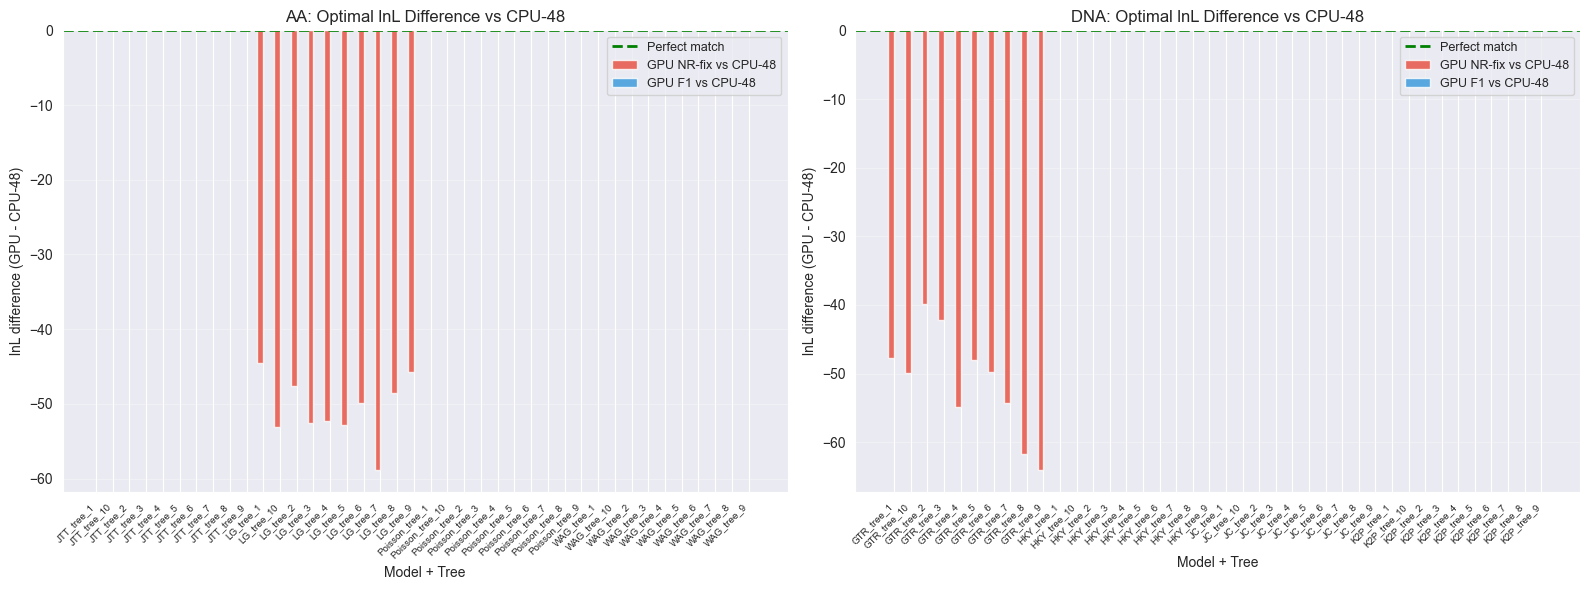

Saved: ll_diff_vs_cpu48.png


In [5]:
# Plot 1: lnL difference bar chart — NR_fix vs CPU-48, grouped by data_type
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, dtype in enumerate(['AA', 'DNA']):
    ax = axes[idx]
    subset = ll_pivot.loc[dtype].copy() if dtype in ll_pivot.index.get_level_values(0) else pd.DataFrame()
    if subset.empty:
        ax.set_visible(False)
        continue
    
    # Only unrooted (NR_fix only has unrooted)
    if 'unrooted' in subset.index.get_level_values(0):
        subset = subset.loc['unrooted']
    
    # Build labels and diffs for both GPU backends
    labels = [f"{m}_{t}" for m, t in subset.index]
    
    x = np.arange(len(labels))
    width = 0.35
    
    if 'GPU_NR_fix_diff' in subset.columns:
        bars1 = ax.bar(x - width/2, subset['GPU_NR_fix_diff'].values, width, 
                       label='GPU NR-fix vs CPU-48', color='#e74c3c', alpha=0.8)
    if 'GPU_F1_diff' in subset.columns:
        bars2 = ax.bar(x + width/2, subset['GPU_F1_diff'].values, width,
                       label='GPU F1 vs CPU-48', color='#3498db', alpha=0.8)
    
    ax.axhline(y=0, color='green', linewidth=2, linestyle='--', label='Perfect match')
    ax.set_xlabel('Model + Tree')
    ax.set_ylabel('lnL difference (GPU - CPU-48)')
    ax.set_title(f'{dtype}: Optimal lnL Difference vs CPU-48')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=7)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'll_diff_vs_cpu48.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ll_diff_vs_cpu48.png")

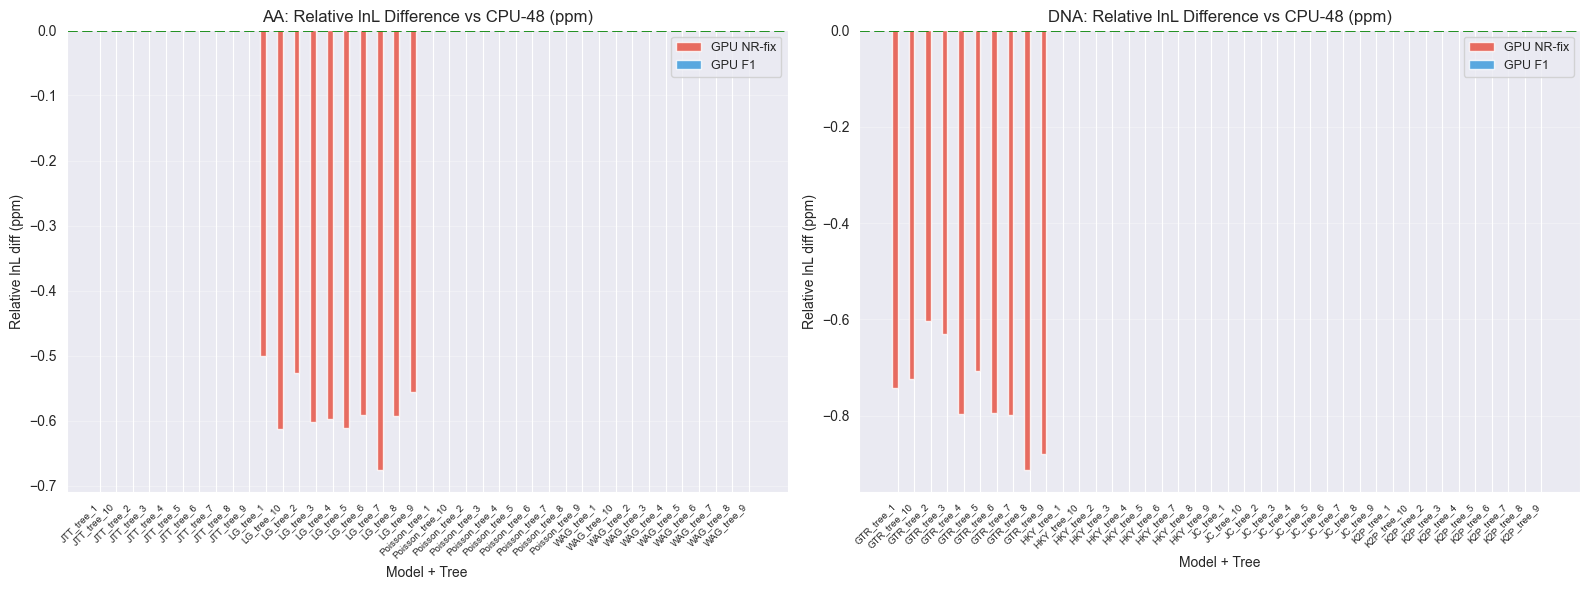

Saved: ll_reldiff_ppm.png


In [6]:
# Plot 2: lnL difference in ppm — NR_fix vs F1 vs CPU
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, dtype in enumerate(['AA', 'DNA']):
    ax = axes[idx]
    subset = ll_pivot.loc[dtype].copy() if dtype in ll_pivot.index.get_level_values(0) else pd.DataFrame()
    if subset.empty:
        ax.set_visible(False)
        continue
    
    if 'unrooted' in subset.index.get_level_values(0):
        subset = subset.loc['unrooted']
    
    labels = [f"{m}_{t}" for m, t in subset.index]
    x = np.arange(len(labels))
    width = 0.35
    
    if 'GPU_NR_fix_reldiff_ppm' in subset.columns:
        ax.bar(x - width/2, subset['GPU_NR_fix_reldiff_ppm'].values, width,
               label='GPU NR-fix', color='#e74c3c', alpha=0.8)
    if 'GPU_F1_reldiff_ppm' in subset.columns:
        ax.bar(x + width/2, subset['GPU_F1_reldiff_ppm'].values, width,
               label='GPU F1', color='#3498db', alpha=0.8)
    
    ax.axhline(y=0, color='green', linewidth=2, linestyle='--')
    ax.set_xlabel('Model + Tree')
    ax.set_ylabel('Relative lnL diff (ppm)')
    ax.set_title(f'{dtype}: Relative lnL Difference vs CPU-48 (ppm)')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=7)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'll_reldiff_ppm.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ll_reldiff_ppm.png")

## 3. Optimization Time Comparison

In [7]:
# Focus on unrooted only (NR_fix only has unrooted)
df_unrooted = df_all[df_all['tree_type'] == 'unrooted'].copy()

# Median opt_time per (data_type, model, treefile, backend)
time_median = df_unrooted.groupby(['data_type', 'model', 'treefile', 'backend'])['opt_time'].median().reset_index()
time_pivot = time_median.pivot_table(index=['data_type', 'model', 'treefile'],
                                      columns='backend', values='opt_time')

# Compute speedups
for gpu_col in ['GPU_NR_fix', 'GPU_F1']:
    if gpu_col in time_pivot.columns:
        if 'CPU_48' in time_pivot.columns:
            time_pivot[f'{gpu_col}_vs_CPU48'] = time_pivot['CPU_48'] / time_pivot[gpu_col]
        if 'CPU_1' in time_pivot.columns:
            time_pivot[f'{gpu_col}_vs_CPU1'] = time_pivot['CPU_1'] / time_pivot[gpu_col]

# NR_fix vs F1 improvement
if 'GPU_NR_fix' in time_pivot.columns and 'GPU_F1' in time_pivot.columns:
    time_pivot['NRfix_vs_F1_speedup'] = time_pivot['GPU_F1'] / time_pivot['GPU_NR_fix']
    time_pivot['NRfix_vs_F1_pct'] = (1 - time_pivot['GPU_NR_fix'] / time_pivot['GPU_F1']) * 100

print("=== Optimization Time Summary (seconds, median across runs) ===")
display_cols = [c for c in ['CPU_1', 'CPU_48', 'GPU_F1', 'GPU_NR_fix'] if c in time_pivot.columns]
print(time_pivot[display_cols].to_string())

=== Optimization Time Summary (seconds, median across runs) ===
backend                        CPU_1   CPU_48   GPU_F1  GPU_NR_fix
data_type model   treefile                                        
AA        JTT     tree_1    273.6600  13.2800  15.4000         NaN
                  tree_10   273.6925  13.4225  15.6125         NaN
                  tree_2    211.9515  11.4045  12.1385         NaN
                  tree_3    211.9640  10.8010  11.9660         NaN
                  tree_4    212.2665  10.9695  12.0810         NaN
                  tree_5    212.3410  10.4495  12.2090         NaN
                  tree_6    275.8565  14.0890  15.4545         NaN
                  tree_7    213.3690  10.9795  12.1710         NaN
                  tree_8    275.6785  17.8725  15.4260         NaN
                  tree_9    212.0740  10.9635  12.1560         NaN
          LG      tree_1    274.3835  13.8395  15.5780     14.6220
                  tree_10   273.5770  13.3895  15.5565     11.237

In [8]:
# Print speedup summary
if 'NRfix_vs_F1_pct' in time_pivot.columns:
    pct = time_pivot['NRfix_vs_F1_pct'].dropna()
    print(f"\n=== NR-fix vs F1 GPU: opt_time improvement ===")
    print(f"  Mean: {pct.mean():.1f}%")
    print(f"  Min:  {pct.min():.1f}%")
    print(f"  Max:  {pct.max():.1f}%")
    print(f"  Median: {pct.median():.1f}%")

for gpu_col in ['GPU_NR_fix', 'GPU_F1']:
    col48 = f'{gpu_col}_vs_CPU48'
    col1  = f'{gpu_col}_vs_CPU1'
    if col48 in time_pivot.columns:
        vals = time_pivot[col48].dropna()
        print(f"\n=== {gpu_col} vs CPU-48 speedup ===")
        print(f"  Mean: {vals.mean():.2f}x")
        print(f"  Min:  {vals.min():.2f}x")
        print(f"  Max:  {vals.max():.2f}x")
    if col1 in time_pivot.columns:
        vals = time_pivot[col1].dropna()
        print(f"\n=== {gpu_col} vs CPU-1 speedup ===")
        print(f"  Mean: {vals.mean():.2f}x")
        print(f"  Min:  {vals.min():.2f}x")
        print(f"  Max:  {vals.max():.2f}x")


=== NR-fix vs F1 GPU: opt_time improvement ===
  Mean: 14.3%
  Min:  3.5%
  Max:  28.1%
  Median: 13.9%

=== GPU_NR_fix vs CPU-48 speedup ===
  Mean: 1.07x
  Min:  0.89x
  Max:  1.39x

=== GPU_NR_fix vs CPU-1 speedup ===
  Mean: 15.84x
  Min:  8.87x
  Max:  24.72x

=== GPU_F1 vs CPU-48 speedup ===
  Mean: 0.80x
  Min:  0.38x
  Max:  1.16x

=== GPU_F1 vs CPU-1 speedup ===
  Mean: 11.99x
  Min:  3.70x
  Max:  18.70x


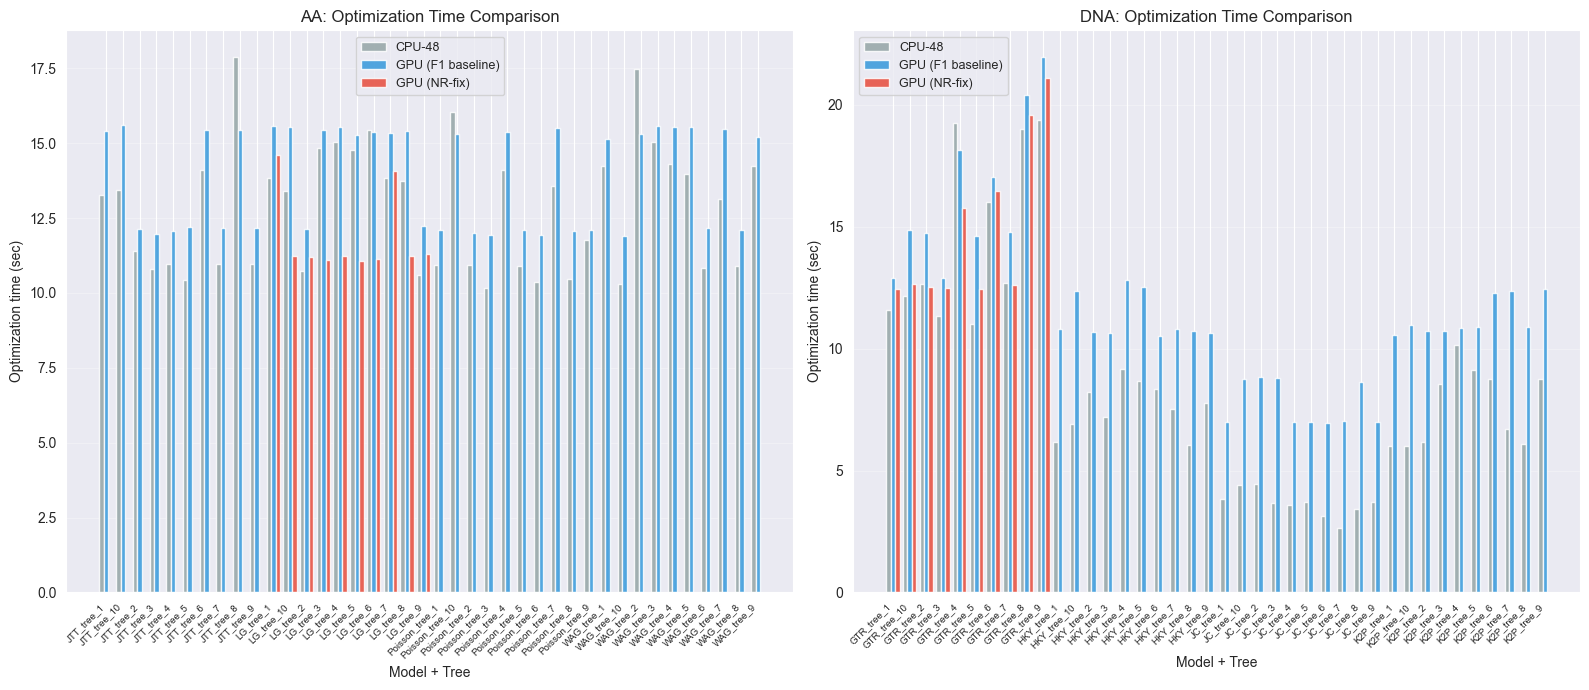

Saved: opt_time_comparison.png


In [9]:
# Plot 3: Optimization time grouped bar chart — NR_fix vs F1 vs CPU-48
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for idx, dtype in enumerate(['AA', 'DNA']):
    ax = axes[idx]
    subset = time_pivot.loc[dtype] if dtype in time_pivot.index.get_level_values(0) else pd.DataFrame()
    if subset.empty:
        ax.set_visible(False)
        continue
    
    labels = [f"{m}_{t}" for m, t in subset.index]
    x = np.arange(len(labels))
    
    backends_to_plot = [c for c in ['CPU_48', 'GPU_F1', 'GPU_NR_fix'] if c in subset.columns]
    n_bars = len(backends_to_plot)
    width = 0.8 / n_bars
    colors = {'CPU_48': '#95a5a6', 'GPU_F1': '#3498db', 'GPU_NR_fix': '#e74c3c'}
    labels_map = {'CPU_48': 'CPU-48', 'GPU_F1': 'GPU (F1 baseline)', 'GPU_NR_fix': 'GPU (NR-fix)'}
    
    for i, backend in enumerate(backends_to_plot):
        offset = (i - n_bars/2 + 0.5) * width
        ax.bar(x + offset, subset[backend].values, width,
               label=labels_map.get(backend, backend),
               color=colors.get(backend, 'gray'), alpha=0.85)
    
    ax.set_xlabel('Model + Tree')
    ax.set_ylabel('Optimization time (sec)')
    ax.set_title(f'{dtype}: Optimization Time Comparison')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=7)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'opt_time_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: opt_time_comparison.png")

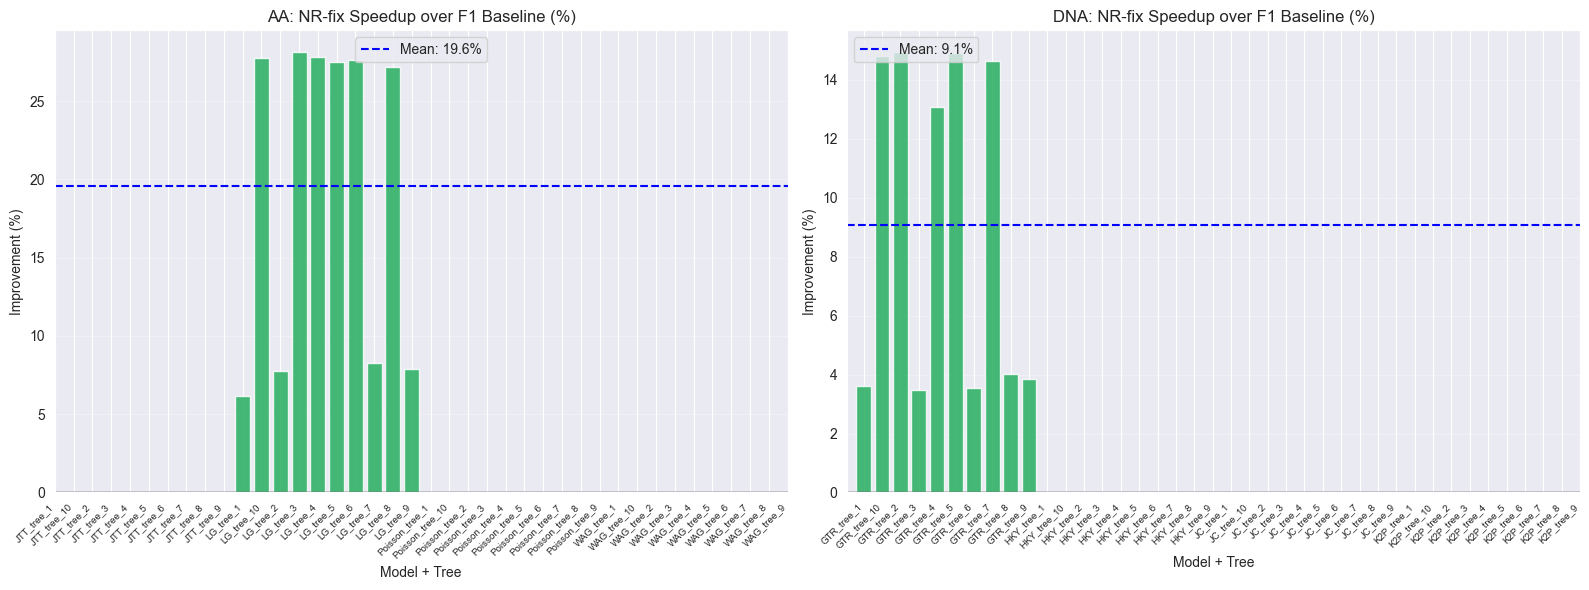

Saved: nrfix_speedup_pct.png


In [10]:
# Plot 4: NR-fix speedup over F1 baseline (% improvement per tree)
if 'NRfix_vs_F1_pct' in time_pivot.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    for idx, dtype in enumerate(['AA', 'DNA']):
        ax = axes[idx]
        subset = time_pivot.loc[dtype] if dtype in time_pivot.index.get_level_values(0) else pd.DataFrame()
        if subset.empty or 'NRfix_vs_F1_pct' not in subset.columns:
            ax.set_visible(False)
            continue
        
        labels = [f"{m}_{t}" for m, t in subset.index]
        vals = subset['NRfix_vs_F1_pct'].values
        colors_bar = ['#27ae60' if v > 0 else '#e74c3c' for v in vals]
        
        ax.bar(range(len(labels)), vals, color=colors_bar, alpha=0.85)
        ax.axhline(y=0, color='black', linewidth=1)
        ax.set_xlabel('Model + Tree')
        ax.set_ylabel('Improvement (%)')
        ax.set_title(f'{dtype}: NR-fix Speedup over F1 Baseline (%)')
        ax.set_xticks(range(len(labels)))
        ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=7)
        ax.grid(axis='y', alpha=0.3)
        
        mean_val = np.nanmean(vals)
        ax.axhline(y=mean_val, color='blue', linewidth=1.5, linestyle='--',
                   label=f'Mean: {mean_val:.1f}%')
        ax.legend(fontsize=10)
    
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'nrfix_speedup_pct.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: nrfix_speedup_pct.png")

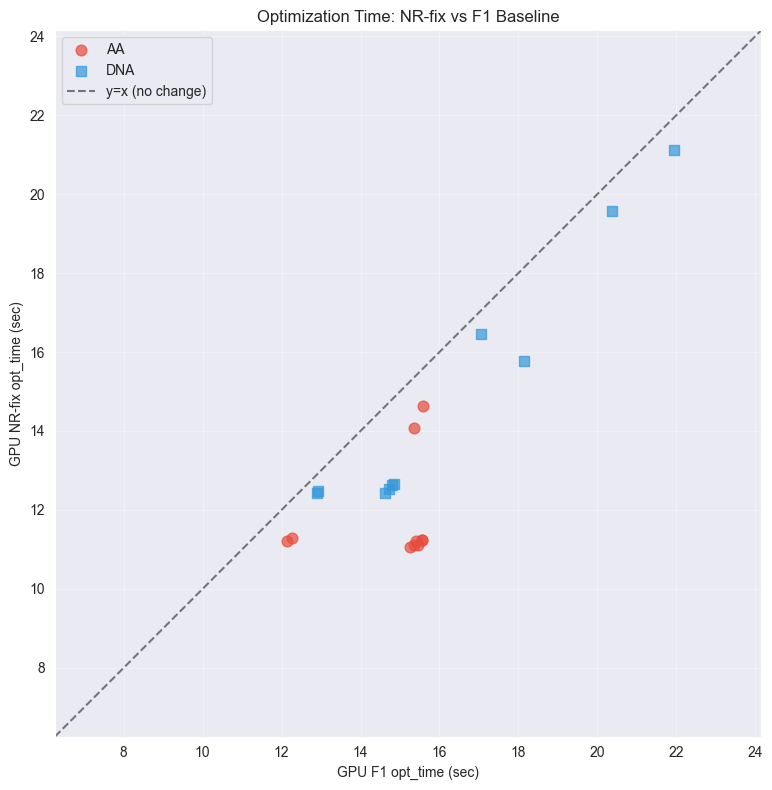

Saved: opt_time_scatter.png


In [11]:
# Plot 5: Scatter — NR_fix opt_time vs F1 opt_time (per model+tree)
if 'GPU_NR_fix' in time_pivot.columns and 'GPU_F1' in time_pivot.columns:
    fig, ax = plt.subplots(figsize=(8, 8))
    
    for dtype in ['AA', 'DNA']:
        if dtype not in time_pivot.index.get_level_values(0):
            continue
        subset = time_pivot.loc[dtype]
        color = '#e74c3c' if dtype == 'AA' else '#3498db'
        marker = 'o' if dtype == 'AA' else 's'
        ax.scatter(subset['GPU_F1'], subset['GPU_NR_fix'], 
                   c=color, marker=marker, s=60, alpha=0.7, label=dtype)
    
    # Identity line
    all_vals = pd.concat([time_pivot['GPU_F1'].dropna(), time_pivot['GPU_NR_fix'].dropna()])
    lims = [all_vals.min() * 0.9, all_vals.max() * 1.1]
    ax.plot(lims, lims, 'k--', alpha=0.5, label='y=x (no change)')
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    
    ax.set_xlabel('GPU F1 opt_time (sec)')
    ax.set_ylabel('GPU NR-fix opt_time (sec)')
    ax.set_title('Optimization Time: NR-fix vs F1 Baseline')
    ax.legend()
    ax.grid(alpha=0.3)
    ax.set_aspect('equal')
    
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'opt_time_scatter.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: opt_time_scatter.png")

## 4. Wall-clock Time Comparison

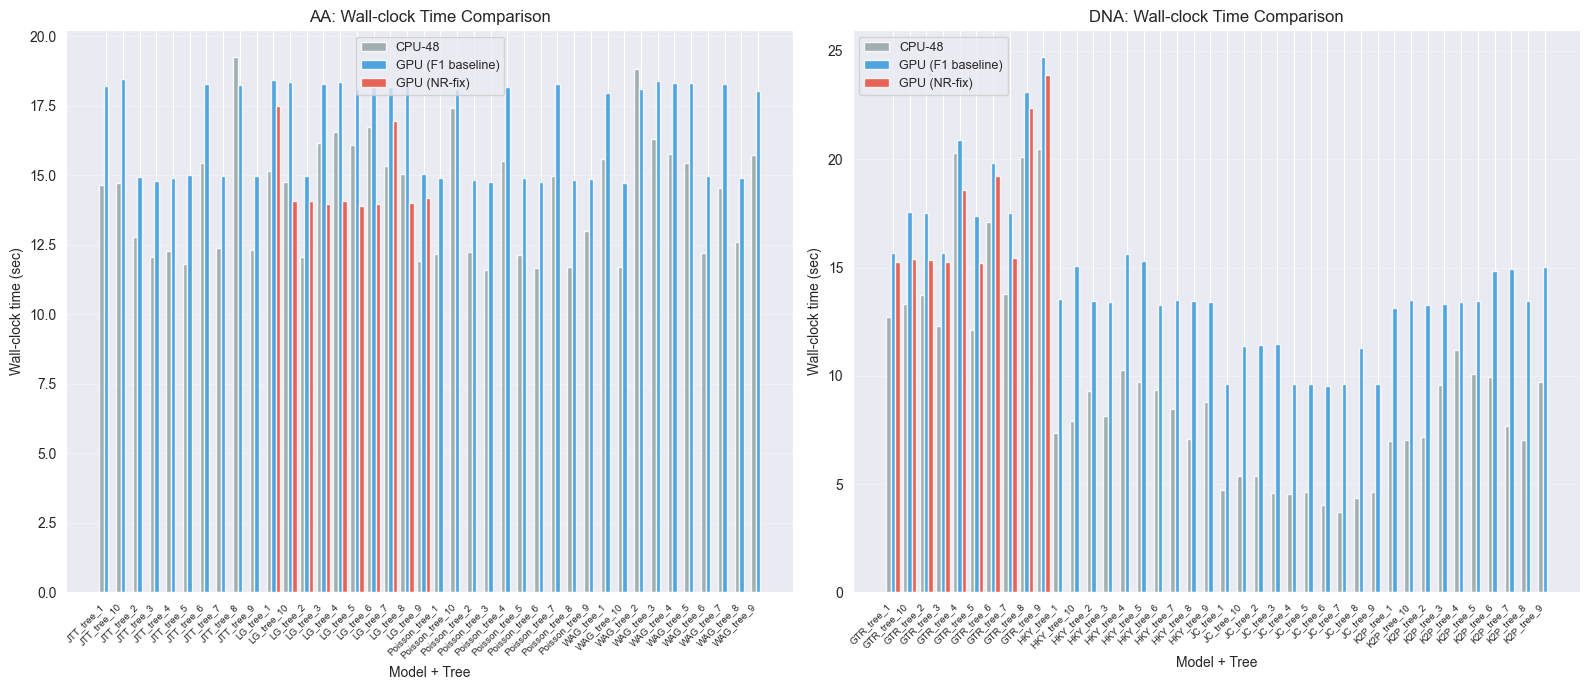

Saved: wallclock_comparison.png


In [12]:
# Wall-clock time comparison
wc_median = df_unrooted.groupby(['data_type', 'model', 'treefile', 'backend'])['wallclock'].median().reset_index()
wc_pivot = wc_median.pivot_table(index=['data_type', 'model', 'treefile'],
                                  columns='backend', values='wallclock')

if 'GPU_NR_fix' in wc_pivot.columns and 'GPU_F1' in wc_pivot.columns:
    wc_pivot['NRfix_vs_F1_pct'] = (1 - wc_pivot['GPU_NR_fix'] / wc_pivot['GPU_F1']) * 100

# Plot 6: Wall-clock grouped bar chart
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for idx, dtype in enumerate(['AA', 'DNA']):
    ax = axes[idx]
    subset = wc_pivot.loc[dtype] if dtype in wc_pivot.index.get_level_values(0) else pd.DataFrame()
    if subset.empty:
        ax.set_visible(False)
        continue
    
    labels = [f"{m}_{t}" for m, t in subset.index]
    x = np.arange(len(labels))
    
    backends_to_plot = [c for c in ['CPU_48', 'GPU_F1', 'GPU_NR_fix'] if c in subset.columns]
    n_bars = len(backends_to_plot)
    width = 0.8 / n_bars
    colors = {'CPU_48': '#95a5a6', 'GPU_F1': '#3498db', 'GPU_NR_fix': '#e74c3c'}
    labels_map = {'CPU_48': 'CPU-48', 'GPU_F1': 'GPU (F1 baseline)', 'GPU_NR_fix': 'GPU (NR-fix)'}
    
    for i, backend in enumerate(backends_to_plot):
        offset = (i - n_bars/2 + 0.5) * width
        ax.bar(x + offset, subset[backend].values, width,
               label=labels_map.get(backend, backend),
               color=colors.get(backend, 'gray'), alpha=0.85)
    
    ax.set_xlabel('Model + Tree')
    ax.set_ylabel('Wall-clock time (sec)')
    ax.set_title(f'{dtype}: Wall-clock Time Comparison')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=7)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'wallclock_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: wallclock_comparison.png")

## 5. Summary: Per-model Averages

In [13]:
# Summary table: per-model averages
summary_rows = []
for dtype in ['AA', 'DNA']:
    if dtype not in time_pivot.index.get_level_values(0):
        continue
    tp = time_pivot.loc[dtype]
    lp = ll_pivot.loc[dtype] if dtype in ll_pivot.index.get_level_values(0) else pd.DataFrame()
    
    for model in tp.index.get_level_values(0).unique():
        tp_m = tp.loc[model]
        row = {'data_type': dtype, 'model': model}
        
        for col in ['CPU_48', 'GPU_F1', 'GPU_NR_fix']:
            if col in tp_m.columns:
                row[f'{col}_opt_time'] = tp_m[col].mean()
        
        if 'NRfix_vs_F1_pct' in tp_m.columns:
            row['NRfix_improvement_%'] = tp_m['NRfix_vs_F1_pct'].mean()
        
        if not lp.empty and 'unrooted' in lp.index.get_level_values(0):
            lp_u = lp.loc['unrooted']
            if model in lp_u.index.get_level_values(0):
                lp_m = lp_u.loc[model]
                if 'GPU_NR_fix_diff' in lp_m.columns:
                    row['NRfix_lnL_diff_mean'] = lp_m['GPU_NR_fix_diff'].mean()
                    row['NRfix_lnL_diff_max'] = lp_m['GPU_NR_fix_diff'].abs().max()
                if 'GPU_F1_diff' in lp_m.columns:
                    row['F1_lnL_diff_mean'] = lp_m['GPU_F1_diff'].mean()
        
        summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
print("=== Summary: Per-Model Averages (unrooted, 10 trees) ===")
print(summary_df.to_string(index=False, float_format='%.3f'))

=== Summary: Per-Model Averages (unrooted, 10 trees) ===
data_type   model  CPU_48_opt_time  GPU_F1_opt_time  GPU_NR_fix_opt_time  NRfix_improvement_%  NRfix_lnL_diff_mean  NRfix_lnL_diff_max  F1_lnL_diff_mean
       AA     JTT           12.423           13.461                  NaN                  NaN                  NaN                 NaN             0.000
       AA      LG           13.621           14.791               11.818               19.591              -50.609              58.923             0.000
       AA Poisson           11.932           13.041                  NaN                  NaN                  NaN                 NaN             0.000
       AA     WAG           13.446           14.392                  NaN                  NaN                  NaN                 NaN             0.000
      DNA     GTR           14.504           16.233               14.803                9.087              -51.254              64.120             0.000
      DNA     HKY        

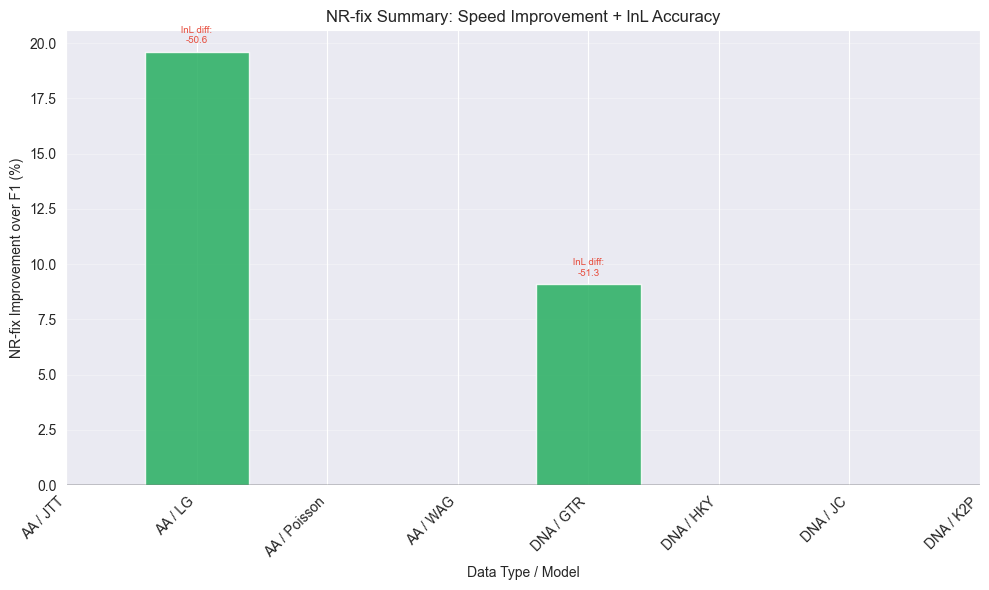

Saved: nrfix_summary.png


In [14]:
# Plot 7: Combined summary — speedup bar + lnL diff annotations
if not summary_df.empty and 'NRfix_improvement_%' in summary_df.columns:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    labels = summary_df['data_type'] + ' / ' + summary_df['model']
    x = np.arange(len(labels))
    vals = summary_df['NRfix_improvement_%'].values
    colors_bar = ['#27ae60' if v > 0 else '#e74c3c' for v in vals]
    
    bars = ax.bar(x, vals, color=colors_bar, alpha=0.85, edgecolor='white')
    
    # Annotate with lnL diff
    if 'NRfix_lnL_diff_mean' in summary_df.columns:
        for i, (bar, ll_diff) in enumerate(zip(bars, summary_df['NRfix_lnL_diff_mean'])):
            if pd.notna(ll_diff):
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                        f'lnL diff:\n{ll_diff:.1f}', ha='center', va='bottom', fontsize=7,
                        color='#e74c3c' if abs(ll_diff) > 0.001 else '#27ae60')
    
    ax.axhline(y=0, color='black', linewidth=1)
    ax.set_xlabel('Data Type / Model')
    ax.set_ylabel('NR-fix Improvement over F1 (%)')
    ax.set_title('NR-fix Summary: Speed Improvement + lnL Accuracy')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'nrfix_summary.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: nrfix_summary.png")

## 6. Run-to-Run Variability

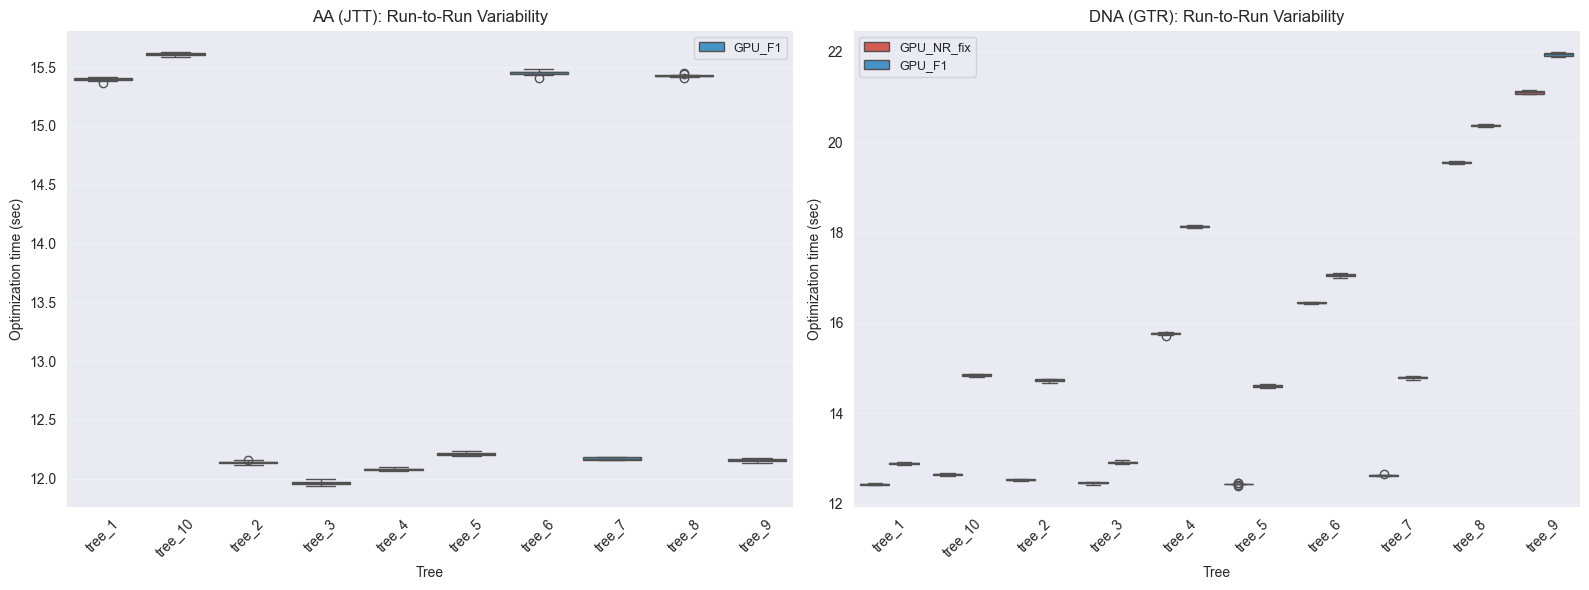

Saved: variability_boxplot.png


In [15]:
# Box plot: run-to-run variability of opt_time for NR_fix vs F1
gpu_runs = df_unrooted[df_unrooted['backend'].isin(['GPU_NR_fix', 'GPU_F1'])].copy()

if not gpu_runs.empty:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    for idx, dtype in enumerate(['AA', 'DNA']):
        ax = axes[idx]
        subset = gpu_runs[gpu_runs['data_type'] == dtype]
        if subset.empty:
            ax.set_visible(False)
            continue
        
        # Pick first model for clarity
        models = sorted(subset['model'].unique())
        subset_m = subset[subset['model'] == models[0]]
        
        sns.boxplot(data=subset_m, x='treefile', y='opt_time', hue='backend',
                    ax=ax, palette={'GPU_NR_fix': '#e74c3c', 'GPU_F1': '#3498db'})
        ax.set_xlabel('Tree')
        ax.set_ylabel('Optimization time (sec)')
        ax.set_title(f'{dtype} ({models[0]}): Run-to-Run Variability')
        ax.tick_params(axis='x', rotation=45)
        ax.legend(fontsize=9)
        ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'variability_boxplot.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: variability_boxplot.png")

## 7. Detailed lnL Table

In [16]:
# Full lnL comparison table
display_ll_cols = [c for c in ['CPU_48', 'GPU_F1', 'GPU_NR_fix', 'GPU_NR_fix_diff', 'GPU_F1_diff'] 
                   if c in ll_pivot.columns]
print("=== Full lnL Comparison (median across runs) ===")
print(ll_pivot[display_ll_cols].to_string(float_format='%.4f'))

# Check: are F1 and CPU-48 identical?
if 'GPU_F1_diff' in ll_pivot.columns:
    f1_diffs = ll_pivot['GPU_F1_diff'].dropna()
    print(f"\nF1 vs CPU-48: max abs diff = {f1_diffs.abs().max():.6f}")
    print(f"F1 matches CPU-48 exactly (< 0.001)? {(f1_diffs.abs() < 0.001).all()}")

if 'GPU_NR_fix_diff' in ll_pivot.columns:
    nr_diffs = ll_pivot['GPU_NR_fix_diff'].dropna()
    print(f"\nNR-fix vs CPU-48: max abs diff = {nr_diffs.abs().max():.6f}")
    print(f"NR-fix matches CPU-48 exactly (< 0.001)? {(nr_diffs.abs() < 0.001).all()}")

=== Full lnL Comparison (median across runs) ===
backend                                       CPU_48          GPU_F1     GPU_NR_fix  GPU_NR_fix_diff  GPU_F1_diff
data_type tree_type model   treefile                                                                             
AA        rooted    JTT     tree_1    -95461509.8310  -95461509.8310            NaN              NaN       0.0000
                            tree_10   -90714872.7630  -90714872.7630            NaN              NaN       0.0000
                            tree_2    -90970159.0540  -90970159.0540            NaN              NaN       0.0000
                            tree_3    -84744167.5290  -84744167.5290            NaN              NaN       0.0000
                            tree_4    -91232353.3580  -91232353.3580            NaN              NaN       0.0000
                            tree_5    -91430861.2960  -91430861.2960            NaN              NaN       0.0000
                            tree_6    -